# 실험 2 — 지갑 2종·10장 Retrieval 실험

## 목적
민준 지갑 5장과 병주 지갑 5장을 함께 후보군에 넣고,
Query와 동일한 실제 지갑의 다른 촬영 이미지가 검색 결과 상위에 배치되는지 확인한다.

## 데이터
- 민준 지갑 5장
- 병주 지갑 5장
- 총 10장

> 이미지 10장을 먼저 `/content`로 Upload to Colab 한 뒤 실행한다.


## 0. GPU 및 실행 환경 확인


In [1]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


## 1. 필요한 라이브러리 설치


In [2]:
%pip install -q -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 116.3 MB/s eta 0:00:0000:010:01


## 2. Colab 업로드 파일 확인


In [3]:
!ls -lh /content

total 36M
-rw-r--r-- 1 root root 4.0M Aug 26 06:53 병주지갑_01.jpg
-rw-r--r-- 1 root root 2.8M Aug 26 06:52 민준지갑_01.jpg
-rw-r--r-- 1 root root 3.2M Aug 26 06:52 민준지갑_02.jpg
-rw-r--r-- 1 root root 4.3M Aug 26 06:54 병주지갑_02.jpg
-rw-r--r-- 1 root root 4.0M Aug 26 06:54 병주지갑_03.jpg
-rw-r--r-- 1 root root 3.8M Aug 26 06:53 민준지갑_03.jpg
-rw-r--r-- 1 root root 3.2M Aug 26 06:53 민준지갑_04.jpg
-rw-r--r-- 1 root root 4.5M Aug 26 06:54 병주지갑_04.jpg
-rw-r--r-- 1 root root 2.9M Aug 26 06:53 민준지갑_05.jpg
-rw-r--r-- 1 root root 3.5M Aug 26 06:54 병주지갑_05.jpg
drwxr-xr-x 1 root root 4.0K Aug 24 13:28 sample_data


## 3. 민준/병주 지갑 10장 데이터셋 로드


In [4]:
from PIL import Image

minjun_files = [
    f"/content/민준지갑_{i:02d}.jpg"
    for i in range(1, 6)
]

byeongju_files = [
    f"/content/병주지갑_{i:02d}.jpg"
    for i in range(1, 6)
]

all_files = minjun_files + byeongju_files

all_images = [
    Image.open(path).convert("RGB")
    for path in all_files
]

labels = [
    "민준_01",
    "민준_02",
    "민준_03",
    "민준_04",
    "민준_05",
    "병주_01",
    "병주_02",
    "병주_03",
    "병주_04",
    "병주_05",
]

print("전체 이미지 개수:", len(all_images))

전체 이미지 개수: 10


## 4. 10장 이미지 시각화


/tmp/ipykernel_1029/2030184182.py:13: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1029/2030184182.py:13: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1029/2030184182.py:13: UserWarning: Glyph 48337 (\N{HANGUL SYLLABLE BYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1029/2030184182.py:13: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.1

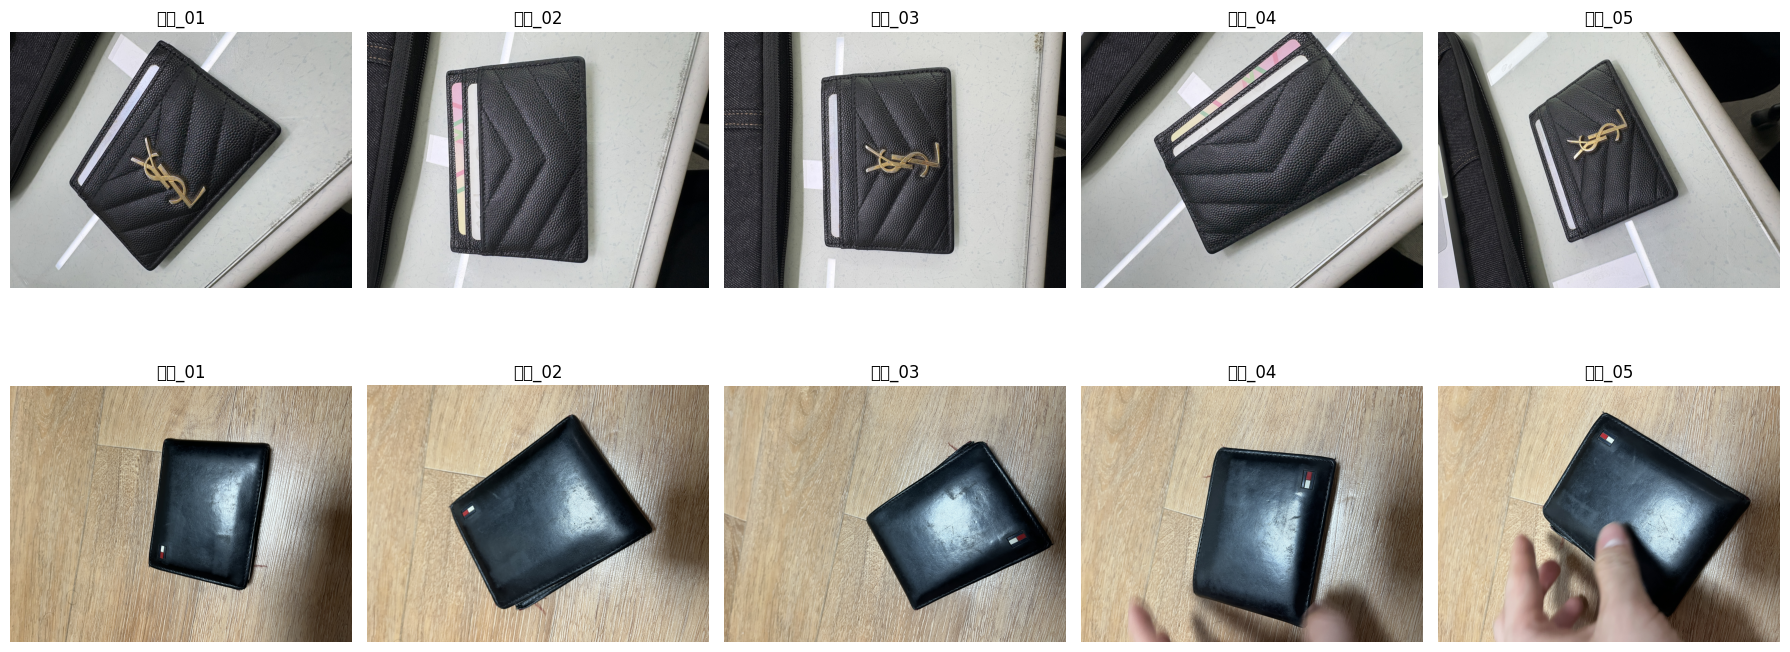

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, image in enumerate(all_images):
    row = i // 5
    col = i % 5

    axes[row, col].imshow(image)
    axes[row, col].set_title(labels[i])
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## 5. SigLIP2 모델 로드


In [6]:
import torch
import torch.nn.functional as F
from transformers import AutoModel, AutoProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"

siglip_model_id = "google/siglip2-base-patch16-224"

siglip_processor = AutoProcessor.from_pretrained(
    siglip_model_id
)

siglip_model = AutoModel.from_pretrained(
    siglip_model_id,
    torch_dtype=torch.float16
).to(device)

siglip_model.eval()

print("SigLIP2 loaded!")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/253 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


tokenizer_config.json:   0%|          | 0.00/47.2k [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

SigLIP2 loaded!


## 6. SigLIP2 임베딩 함수 정의


In [7]:
def get_siglip_embedding(image):
    inputs = siglip_processor(
        images=image,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():
        outputs = siglip_model.get_image_features(**inputs)

    embedding = outputs.pooler_output

    embedding = F.normalize(
        embedding,
        p=2,
        dim=-1
    )

    return embedding

## 7. DINOv2 모델 로드


In [8]:
from transformers import AutoImageProcessor, AutoModel

dino_model_id = "facebook/dinov2-base"

dino_processor = AutoImageProcessor.from_pretrained(
    dino_model_id
)

dino_model = AutoModel.from_pretrained(
    dino_model_id
).to(device)

dino_model.eval()

print("DINOv2 loaded!")

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 loaded!


## 8. DINOv2 임베딩 함수 정의


In [9]:
def get_dino_embedding(image):
    inputs = dino_processor(
        images=image,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():
        outputs = dino_model(**inputs)

    embedding = outputs.pooler_output

    embedding = F.normalize(
        embedding,
        p=2,
        dim=-1
    )

    return embedding

## 9. 10장 전체 SigLIP2 임베딩 생성


In [10]:
siglip_all_embeddings = torch.cat(
    [
        get_siglip_embedding(image)
        for image in all_images
    ],
    dim=0
)

print(
    "SigLIP2 embedding shape:",
    siglip_all_embeddings.shape
)

SigLIP2 embedding shape: torch.Size([10, 768])


## 10. 10장 전체 DINOv2 임베딩 생성


In [11]:
dino_all_embeddings = torch.cat(
    [
        get_dino_embedding(image)
        for image in all_images
    ],
    dim=0
)

print(
    "DINOv2 embedding shape:",
    dino_all_embeddings.shape
)

DINOv2 embedding shape: torch.Size([10, 768])


## 11. Candidate Ranking 함수 정의


In [12]:
def rank_candidates(query_index, embeddings, labels):
    results = []

    query_embedding = embeddings[
        query_index:query_index+1
    ]

    for i in range(len(labels)):

        # 자기 자신 제외
        if i == query_index:
            continue

        score = F.cosine_similarity(
            query_embedding,
            embeddings[i:i+1]
        ).item()

        results.append({
            "label": labels[i],
            "score": score
        })

    results = sorted(
        results,
        key=lambda x: x["score"],
        reverse=True
    )

    return results

## 12. Retrieval 실험 A — 민준_01 Query

민준_01을 Query로 사용하고 자기 자신을 제외한 나머지 9장을 검색한다.
민준_02~05가 Positive, 병주 지갑 5장은 Negative이다.


In [13]:
siglip_results = rank_candidates(
    query_index=0,
    embeddings=siglip_all_embeddings,
    labels=labels
)

dino_results = rank_candidates(
    query_index=0,
    embeddings=dino_all_embeddings,
    labels=labels
)

In [14]:
print("===== SigLIP2 =====")

for rank, result in enumerate(
    siglip_results,
    start=1
):
    print(
        f"{rank:2d}위 | "
        f"{result['label']:<10} | "
        f"{result['score']:.4f}"
    )


print("\n===== DINOv2 =====")

for rank, result in enumerate(
    dino_results,
    start=1
):
    print(
        f"{rank:2d}위 | "
        f"{result['label']:<10} | "
        f"{result['score']:.4f}"
    )

===== SigLIP2 =====
 1위 | 민준_03      | 0.9604
 2위 | 민준_05      | 0.9463
 3위 | 민준_04      | 0.8799
 4위 | 민준_02      | 0.8608
 5위 | 병주_02      | 0.7188
 6위 | 병주_03      | 0.6895
 7위 | 병주_04      | 0.6831
 8위 | 병주_05      | 0.6802
 9위 | 병주_01      | 0.6772

===== DINOv2 =====
 1위 | 민준_05      | 0.8665
 2위 | 민준_04      | 0.8009
 3위 | 민준_03      | 0.7938
 4위 | 민준_02      | 0.7782
 5위 | 병주_04      | 0.6339
 6위 | 병주_01      | 0.6072
 7위 | 병주_02      | 0.6051
 8위 | 병주_05      | 0.6028
 9위 | 병주_03      | 0.5848


## 13. Retrieval 실험 B — 병주_01 Query

검색 방향을 반대로 하여 병주_01을 Query로 사용한다.
병주_02~05가 Positive, 민준 지갑 5장은 Negative이다.


In [15]:
siglip_byeongju_results = rank_candidates(
    query_index=5,
    embeddings=siglip_all_embeddings,
    labels=labels
)

dino_byeongju_results = rank_candidates(
    query_index=5,
    embeddings=dino_all_embeddings,
    labels=labels
)

print("===== Query: 병주_01 =====")

print("\n===== SigLIP2 =====")

for rank, result in enumerate(
    siglip_byeongju_results,
    start=1
):
    print(
        f"{rank:2d}위 | "
        f"{result['label']:<10} | "
        f"{result['score']:.4f}"
    )


print("\n===== DINOv2 =====")

for rank, result in enumerate(
    dino_byeongju_results,
    start=1
):
    print(
        f"{rank:2d}위 | "
        f"{result['label']:<10} | "
        f"{result['score']:.4f}"
    )

===== Query: 병주_01 =====

===== SigLIP2 =====
 1위 | 병주_04      | 0.9683
 2위 | 병주_02      | 0.9541
 3위 | 병주_05      | 0.9395
 4위 | 병주_03      | 0.9375
 5위 | 민준_04      | 0.7412
 6위 | 민준_02      | 0.7378
 7위 | 민준_03      | 0.7090
 8위 | 민준_05      | 0.6978
 9위 | 민준_01      | 0.6772

===== DINOv2 =====
 1위 | 병주_04      | 0.9130
 2위 | 병주_02      | 0.9050
 3위 | 병주_03      | 0.8803
 4위 | 병주_05      | 0.8649
 5위 | 민준_01      | 0.6072
 6위 | 민준_05      | 0.6061
 7위 | 민준_03      | 0.5909
 8위 | 민준_02      | 0.5740
 9위 | 민준_04      | 0.5728


## 실험 2 종료

이 파일은 **2종 지갑 후보군에서 동일 지갑이 검색 순위 상위에 오는지 확인하는 Retrieval 실험**까지 포함한다.
지갑 종류를 4종으로 확장하고 전체 Query를 평가하는 실험은 실험 3에서 수행한다.
